In [11]:
from libraries import*

In [12]:
def lorentz(x, gamma, x0, A): #define lorentz fnc for single peak
    return (A*gamma/(np.pi*((x - x0)**2) + gamma**2))

def lorentz_multi(x, gamma, center, split, A): #define fnc for three peaks
    return  lorentz(x, gamma, center + split, A)+ lorentz(x, gamma, center, A) +  lorentz(x, gamma, center - split, A) 

def lorentz_cluster(x, gamma, center_1, split_1, center_2, split_2, A, offset): #define fnc for cluster of six peaks 
    return lorentz_multi(x, gamma, center_1, split_1, A) + lorentz_multi(x, gamma, center_2, split_2, A) + offset

def lorentz_multi_singlet(x, gamma, center_1, center_2, center_3, A, offset): #define fnc for three individual peaks
     return lorentz(x, gamma, center_1, A) + lorentz(x, gamma, center_2, A) + lorentz(x, gamma, center_3, A) + offset

def lorentz_cluster_singlet(x, gamma, center_1,  center_2, center_3, center_4, center_5, center_6, A, offset): #define fnc for cluster of six individual peaks
        return lorentz(x, gamma, center_1, A) + lorentz(x, gamma, center_2, A)  + lorentz(x, gamma, center_3, A) + lorentz(x, gamma, center_4, A) + lorentz(x, gamma, center_5, A) + lorentz(x, gamma, center_6, A) + offset


In [13]:
path = "/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/" 
numb = 6
steps = 26006
x_start = 100.06
x_end = -106.0
steps_ppm = (x_end - x_start)/steps
x = np.arange(x_start, x_end, steps_ppm)

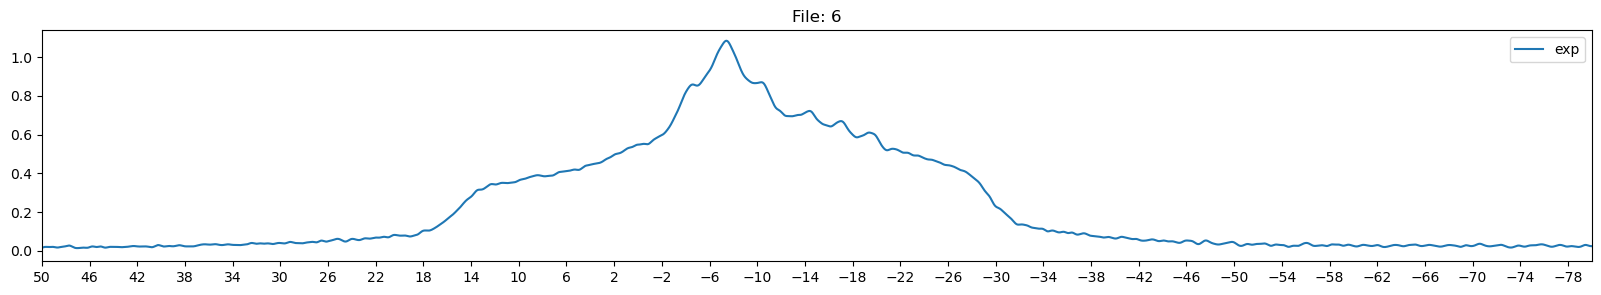

In [14]:
yData = np.loadtxt(path+"SW_Shiva"+str(numb)+".txt", unpack=True)        # read in  
yData = yData / max(yData)                                                # normalize
yData = yData - min(yData)                                                # remove any vertical offset
# Plot the experimental data
plt.figure(figsize=(20,3))
plt.plot(x, yData, '-', label="exp")
plt.xticks(np.arange(min(x), max(x) , 4.0)) 
plt.title("File: "+str(numb))
plt.xlim([50,-80])  
plt.legend()
plt.show()


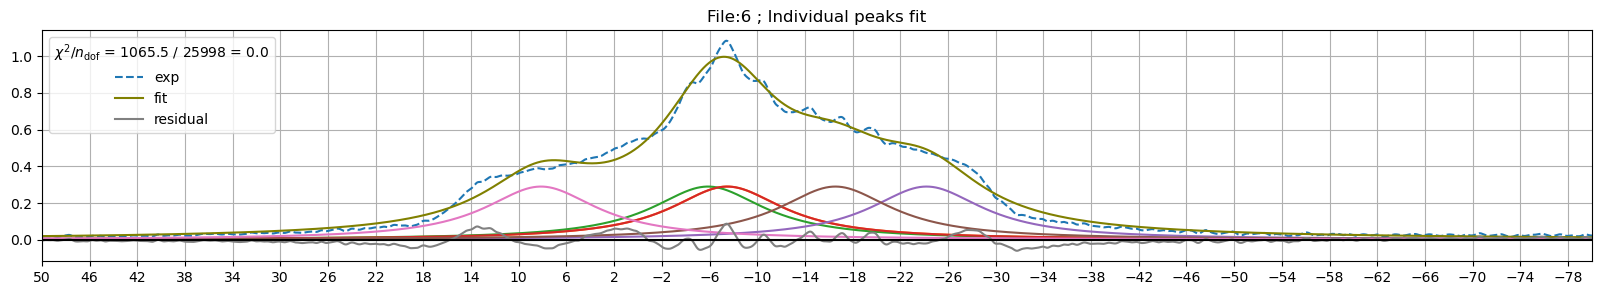

In [24]:
xleft = 50                                                                 # left x limit on plot
xright = -80                                                                 # right x limit on plot
#****************provide information of nucleus*********************************
s = 3/2         #spin of nuclei
clusters = 2    # magnetically different nuclei in unit cell
peaks = int(2*s) #peaks in one cluster

initializer_list = [                                                                    
    {'gamma': 0.001, 'center_1': -5, 'split_1': 1, 'center_2': -16, 'split_2':1, 'A': 1, 'offset': 0.}
]
for initial_values in initializer_list:

    least_squares = LeastSquares(x, yData, 0.1, lorentz_cluster)

    m = Minuit(least_squares, **initial_values).migrad()
    

    #Program to fit individual peaks using initial values from program using center and split parameters

    least_squares_singlet = LeastSquares(x, yData, 0.1, lorentz_cluster_singlet)
    m_singlet = Minuit(least_squares_singlet, gamma = m.values['gamma'], center_1= (m.values['center_1'] -  m.values['split_1']), center_2 =  m.values['center_1'], 
                    center_3 = (m.values['center_1'] + m.values['split_1']), center_4  =  (m.values['center_2'] - m.values['split_2']),center_5 = m.values['center_2'],
                        center_6 =  (m.values['center_2'] + m.values['split_2']), A =  m.values['A'], offset =  m.values['offset']).migrad()

    residual = yData - lorentz_cluster_singlet(x, *m_singlet.values)                                            # finding residual
    row_dict = {'file': numb,'Comment': ''}                                                                     # Define row_dict inside the loop
    # if np.any(np.abs(residual) > 0.1):                                                                        # alert when residual is too large and record in excel file
    #     row_dict['Comment'] = 'Check!!!'
    #     print("\033[91mCheck!!!\033[0m")
    m_singlet_fit_info = [f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_singlet.fval:.1f} / {m_singlet.ndof:.0f} = {m_singlet.fmin.reduced_chi2:.1f}"] 
    #*****************Plotting************************************************
    
    peak_1 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_1'],m_singlet.values['A']) + m_singlet.values['offset'] 
    peak_2 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_2'],m_singlet.values['A']) + m_singlet.values['offset']
    peak_3 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_3'],m_singlet.values['A']) + m_singlet.values['offset']
    peak_4 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_4'],m_singlet.values['A']) + m_singlet.values['offset'] 
    peak_5 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_5'],m_singlet.values['A']) + m_singlet.values['offset']
    peak_6 = lorentz(x, m_singlet.values['gamma'], m_singlet.values['center_6'],m_singlet.values['A']) + m_singlet.values['offset']          

plt.figure(figsize=(20,3))
plt.plot(x, yData, '--', label="exp")
plt.plot(x, lorentz_cluster_singlet(x, *m_singlet.values), label="fit", color = 'olive')  
plt.plot(x,peak_1 )
plt.plot(x, peak_2)
plt.plot(x, peak_3)
plt.plot(x, peak_4)
plt.plot(x, peak_5)
plt.plot(x, peak_6)
plt.xticks(np.arange(min(x), max(x)+1, 4.0)) 
plt.title("File:"+str(numb) + " ;"' Individual peaks fit')
plt.plot(x, residual, color = 'grey', label = "residual")
plt.axhline(y = 0, xmin= x_start, xmax= x_end, color = 'black') #zero reference line
plt.xlim([xleft, xright]) 
plt.grid()
plt.legend(title="\n".join(m_singlet_fit_info), loc='upper left')
plt.show()
